In [2]:
import sys
import importlib
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

sys.path.append("/Users/arthurbenard/Project 1B/src")

In [3]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

my_model = joblib.load('final_xgb_model.joblib')

In [4]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [5]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit, learning_curve, GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [6]:
from data_converter.hplc_data_handler import cleaning_array_by_cas, NMR_SOLVENTS, smiles_to_fingerprint, scrub, compress_fingerprints_pca, calculate_descriptors, extract_solvent_physics, calculate_mlwt
from controller.predictor_runner import generate_ml_ready_file_fingerprint_solvent, generate_ml_ready_file_onehot_solvent, generate_ml_file_with_logs, solubility_file_matrix, add_logs_to_df, add_matrix_id_to_df, run_descriptor_competition, run_hyperparameter_competition, unknown_column_machine_test, strict_unknown_column_machine_test
from analysis.analysis import run_ablation_study, plot_comparison, run_data_fraction, plot_learning_curve, run_ablation_xgboost, learning_curve_trainsize_kselectors, run_matrix_ablation, accuracy_per_matrix, rt_bin_analysis, mw_bin_analysis, solvent_bin_analysis


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/arthurbenard/miniconda3/envs/ml_env/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/arthurbenard/miniconda3/envs/ml_env/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/arthurbenard/miniconda3/envs/ml_env/lib/python3.12/site-packages/ipykernel/kernelapp.py", lin

In [ ]:
def plot_shap_mw_rt_correlation(loaded_model, df, phys_feature_list):
    print("Calculating SHAP values to map the MW/RT interaction\n")
    
    # To explain the AI, we have to feed it data in the exact format it was trained on.
    X_rt = df[['RT']].values 
    X_phys = df[phys_feature_list].values 
    X_mat = np.vstack(df['Matrix_Packed_Array'].values)
    X_final = np.hstack((X_rt, X_phys, X_mat))
    # Create a clean list of names for every single column so the plot has readable labels.
    matrix_names = [f"Matrix_{i+1}" for i in range(10)]
    feature_names = ['RT'] + phys_feature_list + matrix_names
    
    # Unlike standard correlation, TreeExplainer physically reads the XGBoost 
    # decision trees. It uses game theory to calculate exactly how much "credit" each 
    # feature gets for pushing the final prediction toward Soluble (1) or Insoluble (0).
    explainer = shap.TreeExplainer(loaded_model)
    # This returns a matrix identical in size to X_final. Instead of raw physical values
    # it contains the AI's internal impact scores (like "Weight of 200 Da added +0.15 to the solubility probability").
    shap_values = explainer.shap_values(X_final)
    


    
    # Create a nice wide canvas
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # This is the core function that proves interaction between two features.
    shap.dependence_plot(
        "MolWt",                 # Feature for the X-axis
        shap_values,             # The AI's calculated impact scores
        X_final,                 # The raw data
        feature_names=feature_names,
        interaction_index="RT",  # Feature to use for the Color Map
        show=False,              # Wait to show so we can tweak titles
        ax=ax
    )
    
    # Add a custom title
    ax.set_title('AI Learned Interaction: Molecular Weight vs. Retention Time', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Tweak the layout to prevent cut-off labels
    plt.tight_layout()
    plt.show()

In [7]:
# Creating the new dataframe, the first steps can be kept
raw_df = pd.read_excel('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx')
raw_df['SMILES'] = raw_df['solute_smiles'].astype(str).str.strip()

sol_matrix_dirty= pd.read_excel('/Users/arthurbenard/Project 1B/data/Master_Solubility_Matrix.xlsx')
sol_matrix_dirty['SMILES'] = sol_matrix_dirty['solute_smiles'].astype(str).str.strip()

sol_matrix = sol_matrix_dirty.drop_duplicates(subset=['SMILES'], keep='first')

# Deleting rows with signals = 0
raw_df = raw_df[raw_df['RT'] != 0].copy()

# Merges the predicted solubilities with the future df like before
all_dfs_final = []

for sol_name in NMR_SOLVENTS.keys():
    target_col = f"predicted_logS_{sol_name}"
    
    if target_col in sol_matrix.columns:
        temp_raw = raw_df[['SMILES', 'RT', 'Matrix ID Name']].copy()
        temp_sol = sol_matrix[['SMILES', target_col]].copy()
        temp = temp_raw.merge(temp_sol, on='SMILES', how='inner')
        
        if len(temp) > 0:
            temp = temp.rename(columns={target_col: 'logS'})
            temp['Solvent_Name'] = sol_name
            temp['Soluble'] = (temp['logS'] >= -2).astype(int)
            all_dfs_final.append(temp)
            print(f" Added {sol_name}: {len(temp)} rows")
        else:
            print(f" {sol_name}: Merge resulted in 0 rows.")
    else:
        print(f" {target_col} not found in sol_matrix columns.")


# Combines everything
df_desc = pd.concat(all_dfs_final, ignore_index=True)


 Added MeOH: 895 rows
 Added ACN: 895 rows
 Added DMSO: 895 rows
 Added DCM: 895 rows
 Added CHCl3: 895 rows


In [8]:
# Removes 'matrix ID ' in the original column names (was a problem)
df_desc['Matrix ID Name'] = df_desc['Matrix ID Name'].str.replace('matrix ID ', '', regex=False).str.strip()

# The first step is to rename the columns in the given file
matrix_vectors_df = pd.read_excel('/Users/arthurbenard/Project 1B/data/matrixIDs.xlsx')
matrix_vectors_df = matrix_vectors_df.rename(columns={'MatrixID': 'Matrix ID Name'})

# Looks at all the column headers in the file. If the header starts with the letter 'M', adds it to my list.  That way, if new components are 
# given the code adapts easily.
m_cols = [col for col in matrix_vectors_df.columns if col.startswith('M') and col != 'Matrix ID Name']

# Creating a dictionnary, .iterrows() function tells Python to read file line by line and creates key/value pair by grabbing numbers inside m_cols 
# then converting them to decimals then wrapping them in a single array.
matrix_vector_dict = {
    row['Matrix ID Name']: row[m_cols].values.astype(float)
    for _, row in matrix_vectors_df.iterrows()
}

# .map() instantly looks at 'Matrix ID Name' for all rows and attributes the specific array
df_desc['Matrix_Packed_Array'] = df_desc['Matrix ID Name'].map(matrix_vector_dict)


In [9]:
print("1/3 Mapping Solvent Physics...")
unique_solvents = pd.DataFrame({'Solvent_Name': df_desc['Solvent_Name'].unique()})
unique_solvents[['Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']] = unique_solvents['Solvent_Name'].apply(extract_solvent_physics).apply(pd.Series)
df_desc = df_desc.merge(unique_solvents, on='Solvent_Name', how='left')

1/3 Mapping Solvent Physics...


In [11]:
print("2/3 Mapping SMILES Descriptors...")
unique_smiles = pd.DataFrame({'SMILES': df_desc['SMILES'].unique()})
unique_smiles[['MolLogP', 'TPSA', 'MolWt', 'NumHDonors', 'NumHAcceptors']] = unique_smiles['SMILES'].apply(calculate_descriptors).apply(pd.Series)
df_desc = df_desc.merge(unique_smiles, on='SMILES', how='left')

2/3 Mapping SMILES Descriptors...


In [10]:
print("2/3.5 Mapping SMILES Descriptors...")
unique_smiles_other =pd.DataFrame({'SMILES': df_desc['SMILES'].unique()})
unique_smiles_other[['MolWt', 'NumHDonors', 'NumHAcceptors']] = unique_smiles_other['SMILES'].apply(calculate_mlwt).apply(pd.Series)
df_desc = df_desc.merge(unique_smiles_other, on='SMILES', how='left')

2/3.5 Mapping SMILES Descriptors...


In [ ]:
print("3/3 Generating Structural Fingerprints...")
fp_dict = {smi: smiles_to_fingerprint(smi) for smi in df_desc['SMILES'].unique()}
df_desc['Sample Fingerprint'] = df_desc['SMILES'].map(fp_dict)

print(f"\n DATASET GENERATED SUCCESSFULLY")

Calculating SHAP values to map the MW/RT interaction

Generating SHAP Dependence Plot


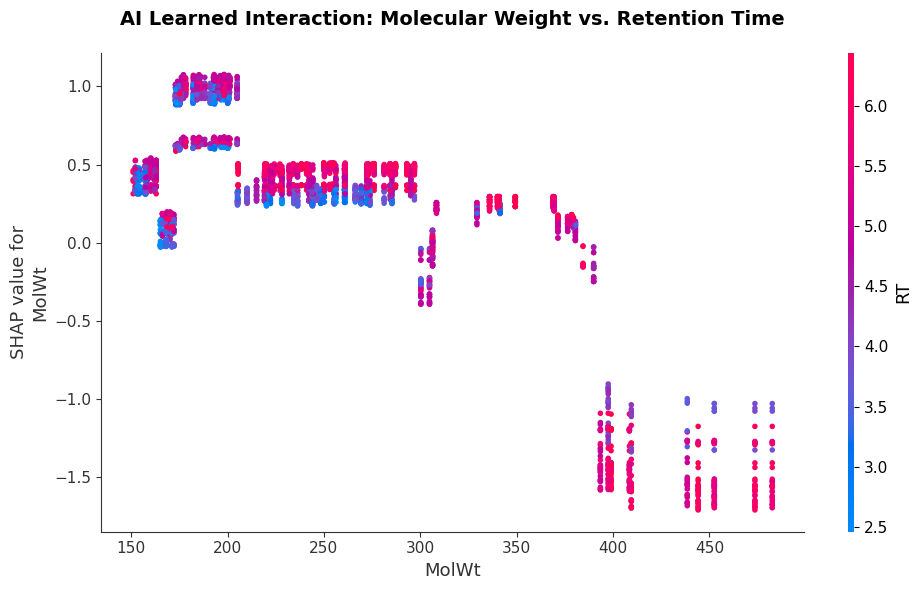

In [16]:
my_features = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
plot_shap_mw_rt_correlation(my_model, df_desc, my_features)

In [24]:
def plot_shap_rt_correlation(loaded_model, df, phys_feature_list):
    
    # To explain the AI, we have to feed it data in the exact format it was trained on.
    X_rt = df[['RT']].values 
    X_phys = df[phys_feature_list].values 
    X_mat = np.vstack(df['Matrix_Packed_Array'].values)
    X_final = np.hstack((X_rt, X_phys, X_mat))
    # Create a clean list of names for every single column so the plot has readable labels.
    matrix_names = [f"Matrix_{i+1}" for i in range(10)]
    feature_names = ['RT'] + phys_feature_list + matrix_names
    
    # Unlike standard correlation, TreeExplainer physically reads the XGBoost 
    # decision trees. It uses game theory to calculate exactly how much "credit" each 
    # feature gets for pushing the final prediction toward Soluble (1) or Insoluble (0).
    explainer = shap.TreeExplainer(loaded_model)
    # This returns a matrix identical in size to X_final. Instead of raw physical values
    # it contains the AI's internal impact scores (like "Weight of 200 Da added +0.15 to the solubility probability").
    shap_values = explainer.shap_values(X_final)
    


    
    # Create a nice wide canvas
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # This is the core function that proves interaction between two features.
    shap.dependence_plot(
        "RT",                 # Feature for the X-axis
        shap_values,             # The AI's calculated impact scores
        X_final,                 # The raw data
        feature_names=feature_names,
        interaction_index=None,  # Feature to use for the Color Map
        show=False,              # Wait to show so we can tweak titles
        ax=ax
    )
    
    # Add a custom title
    ax.set_title('SHAP values for Retention Time', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Tweak the layout to prevent cut-off labels
    plt.tight_layout()
    plt.show()

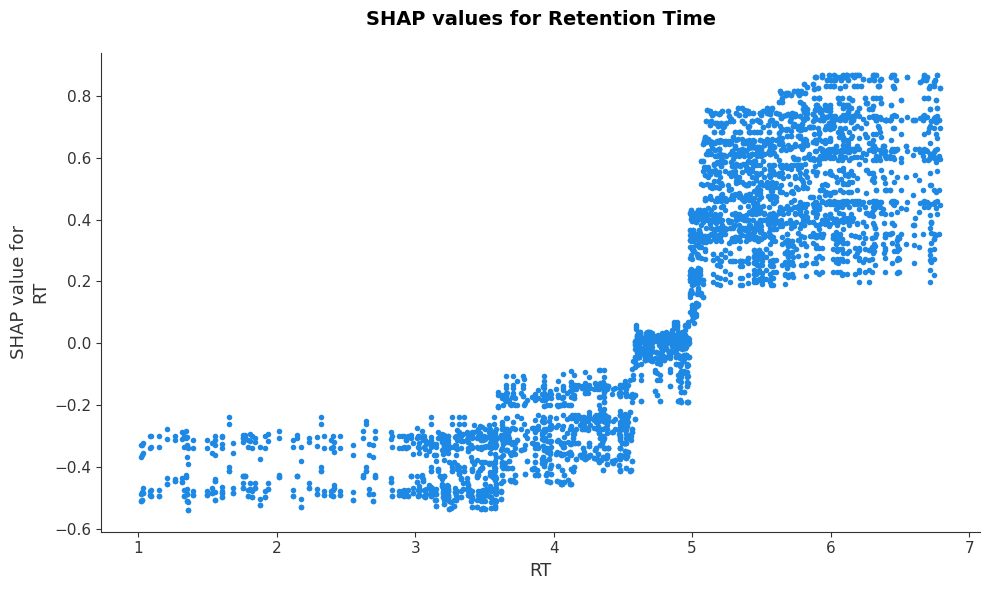

In [25]:
my_features = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']
plot_shap_rt_correlation(my_model, df_desc, my_features)

In [75]:
def plot_custom_shap_categorical(loaded_model, df, phys_feature_list, base_feature, color_col):
    
    X_rt = df[['RT']].values 
    X_phys = df[phys_feature_list].values 
    X_mat = np.vstack(df['Matrix_Packed_Array'].values)
    X_final = np.hstack((X_rt, X_phys, X_mat))
    
    feature_names = ['RT'] + phys_feature_list + [f"Matrix_{i+1}" for i in range(10)]
    
    # --- 2. CALCULATE SHAP VALUES ---
    explainer = shap.TreeExplainer(loaded_model)
    shap_values = explainer.shap_values(X_final)
    
    # --- 3. ISOLATE THE SPECIFIC MATH WE NEED ---
    # Find exactly which column number belongs to our base_feature (e.g., 'MolWt')
    feature_idx = feature_names.index(base_feature)
    
    # Extract only the SHAP values and raw data for that specific feature
    specific_shap_values = shap_values[:, feature_idx]
    specific_feature_data = X_final[:, feature_idx]
    
    # --- 4. THE TRICK: STITCH IT BACK TO THE TEXT DATA ---
    
    plot_df = pd.DataFrame({
        'Raw_Value': specific_feature_data,
        'SHAP_Value': specific_shap_values,
        'Color_Label': df[color_col].values  # Pulling the text directly from the original dataframe!
    })
    
    # --- 5. BUILD THE BEAUTIFUL PLOT ---
    plt.figure(figsize=(11, 6))
    sns.set_theme(style="whitegrid")
    
    # We use seaborn because it handles categorical colors effortlessly
    sns.scatterplot(
        data=plot_df,
        x='Raw_Value',
        y='SHAP_Value',
        hue='Color_Label',
        palette='tab10', # A distinct color palette perfect for different machine/solvent names
        alpha=0.7,
        s=60,
        edgecolor='black',
        linewidth=0.5
    )
    
    # Draw the baseline 0 line
    plt.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
    
    # Add titles and labels
    plt.title(f'AI Decision Matrix', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel(f'{base_feature} (Raw Value)', fontsize=12, fontweight='bold')
    plt.ylabel(f'SHAP Value (Impact on Solubility)', fontsize=12, fontweight='bold')
    
    # Move the legend entirely OUTSIDE the plot so it doesn't block the data dots
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title=color_col, borderaxespad=0)
    
    plt.tight_layout()
    plt.show()

In [11]:
# The target
y = df_desc['Soluble'].values

# Extracting global arrays, stacking them into clean 2D grids
X_mat = np.vstack(df_desc['Matrix_Packed_Array'].values)
X_rt = df_desc[['RT']].values 

# Splitting, ensures ALL models see the exact same train/test rows
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=54)
train_idx, test_idx = next(gss.split(df_desc, y, groups=df_desc['SMILES']))

y_train, y_test = y[train_idx], y[test_idx]

# Calculates a penalty weight
scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)

groups_train = df_desc.iloc[train_idx]['SMILES']

In [72]:
cols_E = [ 'MolWt','Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# Combine RT with the other continuous variables for scaling
X_cont_E = np.hstack((X_rt, df_desc[cols_E].values))
X_train_E_best = np.hstack((X_cont_E[train_idx], X_mat[train_idx]))

X_test_E_best = np.hstack((X_cont_E[test_idx], X_mat[test_idx]))

model_E = xgb.XGBClassifier(n_estimators=1500, learning_rate=0.05, max_depth=15, subsample=0.8,
    colsample_bytree=0.5, gamma=.1, min_child_weight=1, reg_lambda=2, scale_pos_weight=scale_weight, random_state=72, n_jobs=-1)
model_E.fit(X_train_E_best, y_train)

y_pred_E = model_E.predict(X_test_E_best)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_E):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_E, zero_division=0):.4f}\n")

Accuracy:  0.8714
Precision: 0.9066



In [73]:
list_matrix_vectors = [f"Matrix_Vector_M{i+1}" for i in range(X_mat.shape[1])]

selected_names_E = ['RT'] + cols_E + list_matrix_vectors

imp_E = pd.DataFrame({'Feature': selected_names_E, 'Importance': model_E.feature_importances_})

print(" MODEL E FEATURE IMPORTANCES:")
print(imp_E.sort_values(by='Importance', ascending=False).to_string(index=False))

 MODEL E FEATURE IMPORTANCES:
          Feature  Importance
   Sol_Dielectric    0.138909
     Sol_Hansen_P    0.126179
            MolWt    0.103281
     Sol_Hansen_D    0.088305
               RT    0.074406
     Sol_Hansen_H    0.067231
Matrix_Vector_M10    0.052876
 Matrix_Vector_M3    0.046820
 Matrix_Vector_M5    0.043127
 Matrix_Vector_M4    0.040461
 Matrix_Vector_M7    0.039241
 Matrix_Vector_M2    0.038705
 Matrix_Vector_M8    0.038326
 Matrix_Vector_M9    0.036912
 Matrix_Vector_M6    0.034226
 Matrix_Vector_M1    0.030993


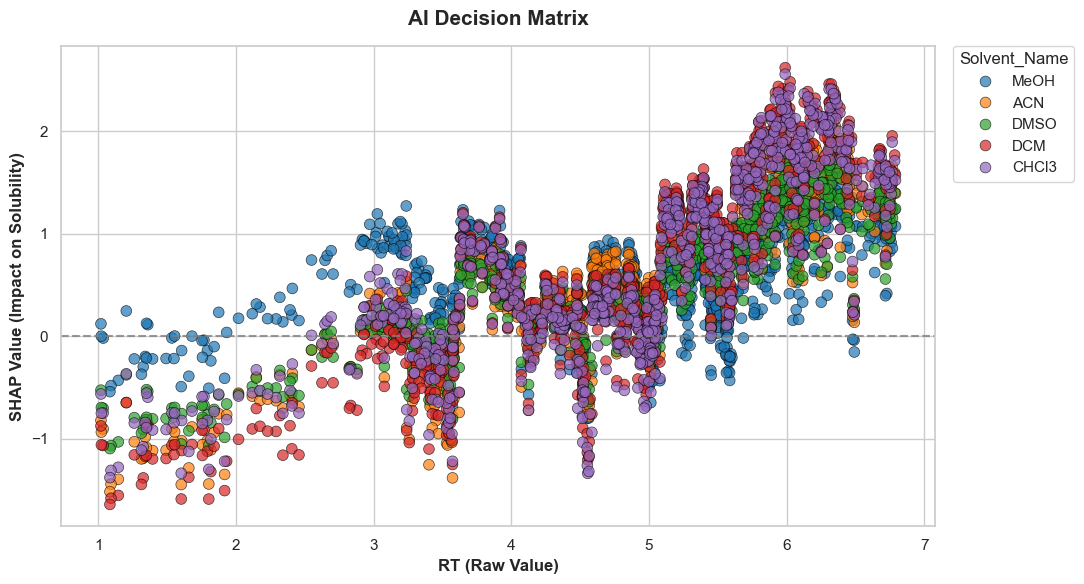

In [77]:
my_features = ['MolWt', 'Sol_Dielectric', 'Sol_Hansen_D', 'Sol_Hansen_P', 'Sol_Hansen_H']

# PLOT 1: Let's see how Molecular Weight interacts with the actual Machine Names
# (Assuming your column is named 'Matrix ID Name')
plot_custom_shap_categorical(model_E, df_desc, my_features, 
                             base_feature='RT', 
                             color_col='Solvent_Name')

In [34]:
def export_confidence_scores(loaded_model, df, phys_feature_list, output_filename="Model_Confidence_Scores.xlsx"):
    
    # --- 1. REBUILD THE EXACT FEATURE MATRIX ---
    X_rt = df[['RT']].values 
    X_phys = df[phys_feature_list].values 
    X_mat = np.vstack(df['Matrix_Packed_Array'].values)
    X_final = np.hstack((X_rt, X_phys, X_mat))
    
    # --- 2. GET THE PREDICTIONS AND PROBABILITIES ---
    # .predict() gives the hard 1 or 0
    predictions = loaded_model.predict(X_final)
    
    # .predict_proba() gives an array with two numbers per row:
    # [Probability of 0, Probability of 1]
    # We want the second column (index 1), which is the % chance of being Soluble.
    probabilities = loaded_model.predict_proba(X_final)[:, 1] 
    
    # --- 3. BUILD A CLEAN DATAFRAME FOR EXCEL ---
    # We are picking the most important columns to look at in Excel
    # (Assuming your molecule names/SMILES are in a column called 'SMILES')
    results_df = pd.DataFrame({
        'Molecule_SMILES': df['SMILES'],           # Change 'SMILES' if your ID column is named differently
        'Matrix_Machine': df['Matrix ID Name'],    # Just to see which machine it ran on
        'Retention_Time': df['RT'],
        'Actual_Solubility': df['Soluble'],        # What actually happened in the lab (0 or 1)
        'AI_Predicted_Class': predictions,         # What the AI guessed (0 or 1)
        'AI_Confidence_Score': probabilities       # The raw % score!
    })
    
    # --- 4. ADD A HELPFUL 'STATUS' COLUMN ---
    # Let's write a quick loop to label exactly what happened for easier sorting in Excel
    conditions = [
        (results_df['Actual_Solubility'] == 1) & (results_df['AI_Predicted_Class'] == 1),
        (results_df['Actual_Solubility'] == 0) & (results_df['AI_Predicted_Class'] == 0),
        (results_df['Actual_Solubility'] == 0) & (results_df['AI_Predicted_Class'] == 1),
        (results_df['Actual_Solubility'] == 1) & (results_df['AI_Predicted_Class'] == 0)
    ]
    choices = ['True Positive (Correct)', 'True Negative (Correct)', 
               'False Positive (Danger)', 'False Negative (Missed)']
    results_df['Result_Type'] = np.select(conditions, choices, default='Unknown')
    
    # --- 5. EXPORT TO EXCEL ---
    print(f"Saving to {output_filename}")
    
    # Save as Excel (you can also use .to_csv('filename.csv', index=False) if you prefer)
    results_df.to_excel(output_filename, index=False)
    
    return results_df

In [35]:
df_results = export_confidence_scores(my_model, df_desc, my_features)

Saving to Model_Confidence_Scores.xlsx
